
# Hospital Readmission Risk Analysis for Diabetic Patients
## Exploratory Analysis

---

<br>
This notebook serves to explore the data from the UCI dataset available at:
<a href="https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008" target="_blank">https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008</a>

According to the authors of the dataset:<br>
"The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge. The problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes."
<br><br>
<div align="center">
    <b>Dataset Characteristics</b>:<br>Multivariate<br><br>
    <b>Subject Area</b>:<br>Health and Medicine<br><br>
    <b>Associated Tasks</b>:<br>Classification, Clustering<br><br>
    <b>Feature Type</b>:<br>Categorical, Integer<br><br>
    <b># Instances</b>:<br>101766<br><br>
    <b># Features</b>:<br>47
</div>
<br>

---
---

#### Imports

In [272]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
import sklearn
from scipy.stats import chi2_contingency

#### Seaborn Config

In [273]:
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 12
pd.set_option('display.max_colwidth', None)

#### Load data set 

In [274]:
diabetes_df = pd.read_csv("../data/raw/diabetic_data.csv")

# Replace missing values placeholder with np.nan
diabetes_df.replace("?",np.nan, inplace=True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


<u>Below is a reference to feature descriptions:</u>

In [275]:
features_df = pd.read_csv("../data/raw/diabetic_data_variables.csv", index_col=0)
target_series = features_df.iloc[-1]
features_df.drop(columns=["units", "demographic", "role"], inplace=True)
features_df.drop([0,1], inplace=True)
features_df.reset_index(drop=True, inplace=True)
display(features_df)

,name,type,description,missing_values
0,race,Categorical,"Values: Caucasian, Asian, African American, Hispanic, and other",yes
1,gender,Categorical,"Values: male, female, and unknown/invalid",no
2,age,Categorical,"Grouped in 10-year intervals: [0, 10), [10, 20),..., [90, 100)",no
3,weight,Categorical,Weight in pounds.,yes
4,admission_type_id,Categorical,"Integer identifier corresponding to 9 distinct values, for example, emergency, urgent, elective, newborn, and not available",no
5,discharge_disposition_id,Categorical,"Integer identifier corresponding to 29 distinct values, for example, discharged to home, expired, and not available",no
6,admission_source_id,Categorical,"Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital",no
7,time_in_hospital,Integer,Integer number of days between admission and discharge,no
8,payer_code,Categorical,"Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay",yes
9,medical_specialty,Categorical,"Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon",yes


In [276]:
# Separate numerical and categorical features
numerical_cols = features_df[features_df["type"]=="Integer"]["name"].to_list()
categorical_cols = features_df[features_df["type"]=="Categorical"]["name"].to_list()[:-1]

print(f"Diabetes dataset has {len(numerical_cols)} numerical and {len(categorical_cols)} categorical features")

Diabetes dataset has 8 numerical and 39 categorical features


### MISSING DATA

#### Checking for Features with Missing Values

In [277]:
# Extract the names of the features with missing values
missing_fearures_names = features_df[features_df["missing_values"] == "yes"]
missing_data_df = diabetes_df[missing_fearures_names["name"]]

display(missing_data_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   race               99493 non-null   str  
 1   weight             3197 non-null    str  
 2   payer_code         61510 non-null   str  
 3   medical_specialty  51817 non-null   str  
 4   diag_1             101745 non-null  str  
 5   diag_2             101408 non-null  str  
 6   diag_3             100343 non-null  str  
dtypes: str(7)
memory usage: 5.4 MB


None

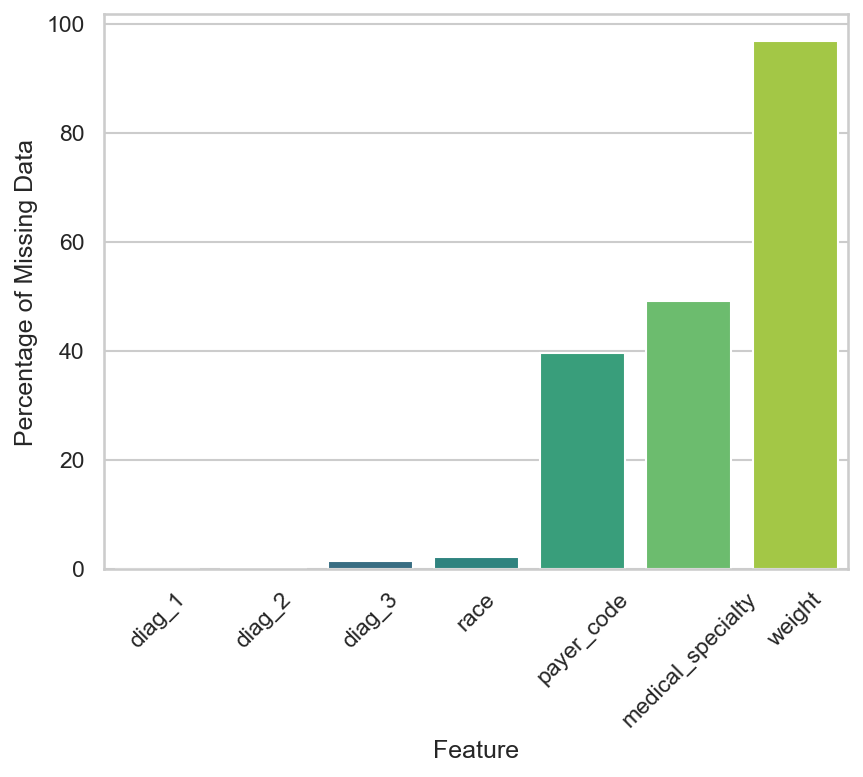

,Missingness (%)
diag_1,0.020636
diag_2,0.351787
diag_3,1.398306
race,2.233555
payer_code,39.557416
medical_specialty,49.082208
weight,96.858479


In [278]:
# Calculate missingness rate and sort
missing_percentages = 100*np.sum(missing_data_df.isna(), axis=0)/missing_data_df.shape[0]
missing_percentages = missing_percentages.sort_values()

sns.barplot(x=missing_percentages.index, y = missing_percentages.values, hue = missing_percentages.index, palette='viridis')
plt.ylabel("Percentage of Missing Data")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.show()
display(pd.DataFrame(missing_percentages, columns = ["Missingness (%)"]))

#### Handling Missing Values

The bar plot shows race, diag_1, diag_2, and diag_3 as having very few null values. Therefore, we will opt to simply delete the rows with missing values for these features.

In [279]:
# Find rows with missing values for ["race", "diag_1", "diag_2", "diag_3"] and drop them
nan_rows = np.any(missing_data_df[["race", "diag_1", "diag_2", "diag_3"]].isna(), axis = 1)
missing_data_df = missing_data_df[~nan_rows]

Weight feature has a ~97% missingness rate and will be dropped completely.

In [280]:
# Drop the `weight` column
missing_data_df = missing_data_df.drop(labels = ["weight"], axis = 1)

# Update missingness rates
missing_percentages = 100*np.sum(missing_data_df.isna(), axis=0)/missing_data_df.shape[0]
missing_percentages = missing_percentages.sort_values()
display(pd.DataFrame(missing_percentages, columns = ["Missingness (%)"]))

,Missingness (%)
race,0.000000
diag_1,0.000000
diag_2,0.000000
diag_3,0.000000
payer_code,39.696899
medical_specialty,49.277432


We are left with `payer_code` and `medical_specialty` with 39% and 49% missingness respectively. Before deciding what to do with these features, we take a look at their description to decide if any domain knowledge can be leveraged to assess their usefulness. 

In [281]:
features_df[features_df["name"].isin(["payer_code", "medical_specialty"])][["name", "description"]]

,name,description
8,payer_code,"Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay"
9,medical_specialty,"Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon"


Since `payer_code` simply tells us the origin of payment (insurance vs self_pay), it is easy to assume it has little value in predicting readmission. We will drop it completely. As for `medical_specialty`, there are a few considerations. From a domain knowledge perspective, knowing what department admitted the patient might have meaningful information. But, it is worth noting that with 84 distinct values, we would risk an explosion of dimensionality if one hot encoding is used for preprocessing of categorical features later. Grouping based encoding or embeddings could minimize this high cardinality but are more complex and require expertise of the medical field. A good place to start instead is to assess the associaltion between this feature and the target. If usefulness is established, more efficient encodings will be considered. Otherwise the feature will be completely dropped. 

In [282]:
# function to calculate Cramier's V between two categorical columns
def cramers_v(x, y):
    # Drop rows where either variable is missing
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    k = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * k))

print("Cramér's V (medical_specialty vs readmitted):", cramers_v(diabetes_df['medical_specialty'], diabetes_df['readmitted']))
print("Cramér's V (payer_code vs readmitted):", cramers_v(diabetes_df['payer_code'], diabetes_df['readmitted']))

Cramér's V (medical_specialty vs readmitted): 0.10844492507840839
Cramér's V (payer_code vs readmitted): 0.06422447751635021


Based on the above Cramér's V results, both `medical_specialty` (Cramér's V ≈ 0.11) and `payer_code` (Cramér's V ≈ 0.06) show low association with the target variable. Combined with their high missingness rates (49% and 39% respectively), both features will be dropped from further analysis.

In [283]:
# Drop `medical_specialty` and `payer_code` columns
missing_data_df = missing_data_df.drop(labels = ["medical_specialty", "payer_code"], axis = 1)

# Combine the fixed missingness dataframe with the non-missing features to reconstruct the cleaned data
# Select features that had no missing values
none_missing_features = features_df[features_df["missing_values"] == "no"]["name"]
# Copy those columns from the original dataframe
non_missing_df = diabetes_df[none_missing_features].copy()
# Concatenate non-missing and now-complete missingness columns along columns axis
missingness_fixed_diabetes_df = pd.concat([missing_data_df, non_missing_df], axis=1)
missingness_fixed_diabetes_df.head()

,race,diag_1,diag_2,diag_3,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,Caucasian,276,250.01,255,Female,[10-20),1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,648,250,V27,Female,[20-30),1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,8,250.43,403,Male,[30-40),1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,197,157,250,Male,[40-50),1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,414,411,250,Male,[50-60),2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [ ]:
# Drop "weight", "medical_specialty", and "payer_code" from features_df and reset index
features_df = features_df[~features_df["name"].isin(["weight", "medical_specialty", "payer_code"])]
features_df = features_df.reset_index(drop=True)
features_df

,name,type,description,missing_values
0,race,Categorical,"Values: Caucasian, Asian, African American, Hispanic, and other",yes
1,gender,Categorical,"Values: male, female, and unknown/invalid",no
2,age,Categorical,"Grouped in 10-year intervals: [0, 10), [10, 20),..., [90, 100)",no
3,admission_type_id,Categorical,"Integer identifier corresponding to 9 distinct values, for example, emergency, urgent, elective, newborn, and not available",no
4,discharge_disposition_id,Categorical,"Integer identifier corresponding to 29 distinct values, for example, discharged to home, expired, and not available",no
5,admission_source_id,Categorical,"Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital",no
6,time_in_hospital,Integer,Integer number of days between admission and discharge,no
7,num_lab_procedures,Integer,Number of lab tests performed during the encounter,no
8,num_procedures,Integer,Number of procedures (other than lab tests) performed during the encounter,no
9,num_medications,Integer,Number of distinct generic names administered during the encounter,no


### Association Analysis

#### Cramier's V

In [285]:
feature_names = diabetes_df[categorical_cols].columns.to_list()
cr_v_scores = []
for feature in feature_names:
    cr_v_scores.append(cramers_v(diabetes_df[feature], diabetes_df['readmitted']))


display(pd.DataFrame(data=cr_v_scores, index = feature_names, columns = ["Cramier's V"]).sort_values(by="Cramier's V"))

/var/folders/rs/nxr9z_ls7qn181t7xwjm7gtm0000gn/T/ipykernel_23603/1219968167.py:11: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * k))
/var/folders/rs/nxr9z_ls7qn181t7xwjm7gtm0000gn/T/ipykernel_23603/1219968167.py:11: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * k))


,Cramier's V
metformin-pioglitazone,0.002898
troglitazone,0.003756
tolbutamide,0.004008
metformin-rosiglitazone,0.004099
nateglinide,0.004101
acetohexamide,0.004279
glimepiride-pioglitazone,0.004279
glipizide-metformin,0.004486
tolazamide,0.004999
glyburide-metformin,0.006472


### ETA Squared 

In [286]:
from scipy.stats import f_oneway

def eta_squared(feature, target):
    groups = [feature[target == cls].dropna() for cls in target.unique()]
    grand_mean = feature.dropna().mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((feature.dropna() - grand_mean)**2)
    return ss_between / ss_total

eta_squared(df['num_medications'], df['target'])

NameError: name 'df' is not defined

In [ ]:
diabetes_df["diag_1"].unique()


<StringArray>
['250.83',    '276',    '648',      '8',    '197',    '414',    '428',
    '398',    '434',  '250.7',
 ...
     '58',    '649',    '832',    '133',    '975',    '833',    '391',
    '690',     '10',    'V51']
Length: 717, dtype: str

### TRAIN-TEST SPLIT (before all data transformations that use computed statistics)

### OUTLIERS

### IMBALANCE

### FEATURE/TARGET DISTRIBUTIONS

### FEATURE IMPORTANCE

### RELATIONSHIPS

### DIMENSIONALITY REDUCTION

## PIPELINE AND MODELING

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

categorical_cols = ['diag_1', 'diag_2', 'diag_3', 'admission_type_id', ...]
numerical_cols = ['num_lab_procedures', 'num_medications', ...]

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown'))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  # optional, tree models don't need scaling
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(categorical_features=categorical_cols))
])

pipeline.fit(X_train, y_train)

NameError: name 'LogisticRegression' is not defined

# Playground